# GFlowNet for LET-7 miRNA Sequences (22bp)

FL-DB training on 612 real miRNA sequences (69 unique variants, 22bp).
State space: 4^22 ~ 17.6 trillion, target density ~3.9e-12.

In [ ]:
import time
import json
import torch
import matplotlib.pyplot as plt
from collections import Counter

from gfn import train_fast, FastTrainingConfig
from gfn.reward import HammingReward, EntropyWeightedHammingReward, AdaptiveHammingReward

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## Load LET-7 miRNA Sequences

In [ ]:
with open('data/LET7_22bp_targets.json', 'r') as f:
    targets_dict = json.load(f)

target_sequences = [list(seq) for seq in targets_dict.values()]
target_names = list(targets_dict.keys())

unique_seqs = set(targets_dict.values())
seq_len = len(target_sequences[0])
n_targets = len(target_sequences)
n_unique = len(unique_seqs)
state_space = 4 ** seq_len

print(f"Total targets: {n_targets}, unique: {n_unique}")
print(f"Sequence length: {seq_len}bp")
print(f"State space: 4^{seq_len} = {state_space:,}")
print(f"Target density: {n_unique / state_space:.2e}")
print(f"\nFirst 5 sequences:")
for name, seq in list(targets_dict.items())[:5]:
    print(f"  {name}: {seq}")

## Sequence Diversity

In [ ]:
import numpy as np

unique_seqs = set(targets_dict.values())
print(f"Unique sequences: {len(unique_seqs)} / {n_targets}")

seq_counts = Counter(targets_dict.values())
print(f"\nTop 15 sequence variants (by frequency):")
for seq, count in seq_counts.most_common(15):
    print(f"  {seq}: {count} species")
if len(seq_counts) > 15:
    print(f"  ... and {len(seq_counts) - 15} more unique sequences")

# Pairwise Hamming distances among unique sequences
seqs_list = list(unique_seqs)
all_dists = []
for i, s1 in enumerate(seqs_list):
    for j, s2 in enumerate(seqs_list):
        if i < j:
            dist = sum(a != b for a, b in zip(s1, s2))
            all_dists.append(dist)

print(f"\nHamming distance statistics ({len(all_dists)} pairs):")
print(f"  Min: {min(all_dists)}, Max: {max(all_dists)}")
print(f"  Mean: {np.mean(all_dists):.2f}, Median: {np.median(all_dists):.1f}")

## Reward Function

In [ ]:
REWARD_SCHEME = 'entropy'  # 'basic', 'entropy', or 'adaptive'

ENTROPY_WEIGHT = 1.0
DECAY_RATE = 0.5
MIN_MULTIPLIER = 0.1

print(f"Reward scheme: {REWARD_SCHEME}")

In [ ]:
if REWARD_SCHEME == 'basic':
    reward_fn = HammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.01,
        device='cuda',
    )
elif REWARD_SCHEME == 'entropy':
    reward_fn = EntropyWeightedHammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.01,
        device='cuda',
        entropy_weight=ENTROPY_WEIGHT,
    )
elif REWARD_SCHEME == 'adaptive':
    reward_fn = AdaptiveHammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.01,
        device='cuda',
        decay_rate=DECAY_RATE,
        min_multiplier=MIN_MULTIPLIER,
    )
else:
    raise ValueError(f"Unknown reward scheme: {REWARD_SCHEME}")

print(f"Using: {type(reward_fn).__name__}")
print(f"GPU batch support: {reward_fn.supports_batch}, device: {reward_fn.device}")

## Training Configuration

In [ ]:
config = FastTrainingConfig(
    alphabet=['A', 'U', 'G', 'C'],
    max_seq_len=22,
    seed=42,
    hidden_layers=[128, 64, 32],
    batch_size=4096,
    n_iterations=200,
    learning_rate=3e-3,
    device='cuda',
    objective='FLDB',
    target_sequences=target_sequences,
    explore_ratio=0.3,
    temperature=2.0,
    insert_only=True,
)

print(f"FL-DB config: {config.max_seq_len}bp, {config.n_timesteps} timesteps")
print(f"Total episodes: {config.batch_size * config.n_iterations:,}")
print(f"Hidden layers: {config.hidden_layers}")
print(f"Exploration: eps={config.explore_ratio}, T={config.temperature}")
print(f"Search space: {config.search_space_size:,} terminal states")
print(f"Target density: {n_unique / config.search_space_size:.2e}")

## Train

In [ ]:
# start_time = time.time()
# result = train_fast(reward_fn, config, verbose=True)
# train_time = time.time() - start_time
# 
# print(f"\nCompleted in {train_time:.2f}s, Z={result.final_Z:.2f}")
# if result.hit_rates:
#     print(f"Final hit rate = {result.final_hit_rate*100:.4f}%")
# if result.target_coverages:
#     print(f"Target coverage = {result.n_unique_targets_hit}/{result.n_targets} ({result.target_coverages[-1]*100:.1f}%)")

In [ ]:
from gfn import TrainingResult
result = TrainingResult.load('results/fldb_LET7_22bp_20260128_050725/final')

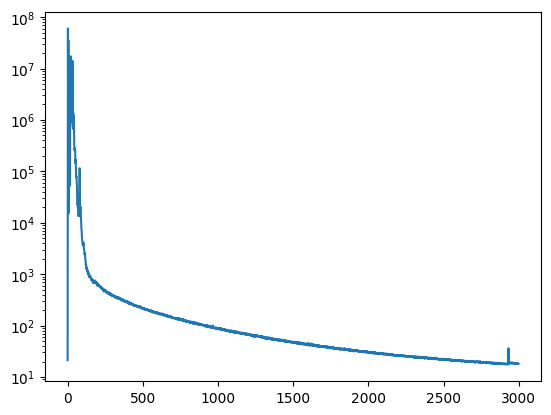

In [8]:
plt.plot(result.losses)
plt.yscale('log')

In [9]:
for state in result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε')
    print(seq)

UUGUAGUAUUUGUUACUCAACA
AUUAGCUUCUCUCCAGGACAAA
GCAGUAUUCUUAGGAUUCCUCG
GCUGGCUACGCAGUAGAGCUUG
GAGUUGGAUGAAUUUGCCUGCA
CUGACCCGUGUGUAAAGCUGGC
AUCCUUCAAGUCGGAGAGCCAG
UUACCUAAGAUCACGGCUAGGA
UGCGCUCCGCGGAGCUAACGUG
UGGUUUAAGGCGGGACUACCCG
GUGUACAGUGACACAAAAGAUC
CAAAGUAGCACUUCUCUGGUAC
UUGACCUCGUGGUAAACGACAG
UCAGCCAGCGUCCAAUACAGGA
UCGUAUUGACUUGUAAGGCCCU
UAGAGUGUACGUAUCCUGGAAC
UACGCUUUGUUGGUCGGCUACA
GCAUUAAUAGAUACGUCCCGCC
CCCGGACUUCGGAUACGGAGGA
UCGUAACCUUGACUGUCUCUCA


## Training Curves

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(result.losses, alpha=0.8, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('FL-DB Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(result.logZs, alpha=0.8, color='green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Log Z')
ax2.set_title('Partition Function Estimate')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
if result.hit_rates:
    ax3.plot(result.hit_rates, alpha=0.8, color='orange')
    ax3.axhline(y=n_targets/state_space, color='red', linestyle='--', 
                label=f'Random baseline ({n_targets/state_space:.2e})')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Target Hit Rate per Batch')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
if result.target_coverages:
    ax4.plot(result.target_coverages, alpha=0.8, color='purple')
    ax4.axhline(y=1.0, color='green', linestyle='--', label='100% coverage')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Coverage')
ax4.set_title(f'Cumulative Target Coverage ({n_targets} targets)')
ax4.set_ylim(0, 1.05)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'FL-DB Training on LET-7 miRNA (22bp, {n_targets} targets)', fontsize=14)
plt.tight_layout()
plt.show()

## Generated Sequences

In [ ]:
target_set = set(''.join(seq) for seq in target_sequences)

print("Last 20 generated sequences:")
for state in result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε')
    is_target = seq in target_set
    marker = " *TARGET" if is_target else ""
    print(f"  {seq}{marker}")

all_generated = [''.join(s for s in state[1] if s != 'ε') for state in result.sampled_states]
generated_targets = [seq for seq in all_generated if seq in target_set]

print(f"\nTotal samples: {len(result.sampled_states)}")
print(f"Target hits in samples: {len(generated_targets)}")

In [ ]:
# Analyze sequence length distribution
lengths = [len([c for c in state[1] if c != 'ε']) for state in result.sampled_states]
length_counts = Counter(lengths)

print("Sequence length distribution:")
for length, count in sorted(length_counts.items()):
    print(f"  Length {length}: {count} ({count/len(lengths)*100:.1f}%)")

## Hit Trajectory Analysis

In [ ]:
if result.hit_trajectories:
    stats = result.get_hit_stats()
    
    print(f"Total hits: {stats['total_hits']}")
    print(f"Unique targets hit: {stats['unique_targets']} / {result.n_targets}")
    print(f"First hit iteration: {stats['first_hit_iteration']}")
    print(f"Hits in last 10% iterations: {stats['hits_in_last_10pct']}")
    
    print(f"\nTargets hit (by frequency):")
    hit_seqs = Counter([''.join(h.sequence) for h in result.hit_trajectories])
    for seq, count in hit_seqs.most_common(10):
        species = [name for name, s in targets_dict.items() if s == seq]
        species_str = species[0] if len(species) == 1 else f"{len(species)} species"
        print(f"  {seq}: {count} hits ({species_str})")
else:
    print("No target hits recorded during training.")

## Similarity Analysis

In [ ]:
from gfn import TrainingResult
import json
import numpy as np
from collections import Counter

result = TrainingResult.load('results/fldb_LET7_22bp_20260128_050725/final')

with open('data/LET7_22bp_targets.json', 'r') as f:
    targets_dict = json.load(f)
target_seqs = list(set(targets_dict.values()))

print(f"Loaded {len(result.sampled_states)} sampled states")
print(f"Target sequences: {len(target_seqs)} unique")

In [ ]:
def hamming_similarity(seq1, seq2):
    if len(seq1) != len(seq2):
        min_len = min(len(seq1), len(seq2))
        seq1, seq2 = seq1[:min_len], seq2[:min_len]
    if len(seq1) == 0:
        return 0.0
    matches = sum(a == b for a, b in zip(seq1, seq2))
    return matches / len(seq1)

def max_similarity_to_targets(seq, targets):
    return max(hamming_similarity(seq, t) for t in targets)

generated_seqs = []
for state in result.sampled_states:
    seq = ''.join(s for s in state[1] if s != 'ε')
    if len(seq) == 22:
        generated_seqs.append(seq)

print(f"Generated sequences (22bp): {len(generated_seqs)}")

similarities = [max_similarity_to_targets(seq, target_seqs) for seq in generated_seqs]

print(f"\nSimilarity to nearest target:")
print(f"  Min: {min(similarities):.3f} ({min(similarities)*22:.1f}/22 matches)")
print(f"  Max: {max(similarities):.3f} ({max(similarities)*22:.1f}/22 matches)")
print(f"  Mean: {np.mean(similarities):.3f} ({np.mean(similarities)*22:.1f}/22 matches)")
print(f"  Median: {np.median(similarities):.3f}")
print(f"\nRandom baseline (expected): 0.250 (5.5/22 matches)")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(similarities, bins=20, edgecolor='black', alpha=0.7)
ax1.axvline(x=0.25, color='red', linestyle='--', label='Random baseline (25%)')
ax1.axvline(x=1.0, color='green', linestyle='--', label='Perfect match')
ax1.set_xlabel('Max Similarity to Any Target')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Generated Sequence Similarities')
ax1.legend()
ax1.grid(True, alpha=0.3)

top_k = 10
sorted_pairs = sorted(zip(generated_seqs, similarities), key=lambda x: -x[1])

ax2 = axes[1]
top_sims = [s for _, s in sorted_pairs[:top_k]]
ax2.barh(range(top_k), top_sims, color='steelblue')
ax2.set_yticks(range(top_k))
ax2.set_yticklabels([f"#{i+1}" for i in range(top_k)])
ax2.set_xlabel('Similarity')
ax2.set_title(f'Top {top_k} Most Similar Generated Sequences')
ax2.set_xlim(0, 1)
ax2.axvline(x=0.25, color='red', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Top 10 most similar generated sequences:")

for i, (gen_seq, sim) in enumerate(sorted_pairs[:10]):
    best_target = max(target_seqs, key=lambda t: hamming_similarity(gen_seq, t))
    match_str = ''.join('|' if a == b else ' ' for a, b in zip(gen_seq, best_target))
    n_matches = int(sim * 22)
    
    print(f"\n#{i+1} Similarity: {sim:.3f} ({n_matches}/22 matches)")
    print(f"  Generated: {gen_seq}")
    print(f"  Match:     {match_str}")
    print(f"  Target:    {best_target}")

In [ ]:
# Per-position base frequency: targets vs generated
target_freq = np.zeros((22, 4))
base_to_idx = {'A': 0, 'U': 1, 'G': 2, 'C': 3}

for seq in target_seqs:
    for i, base in enumerate(seq):
        if base in base_to_idx:
            target_freq[i, base_to_idx[base]] += 1
target_freq /= len(target_seqs)

gen_freq = np.zeros((22, 4))
for seq in generated_seqs:
    for i, base in enumerate(seq):
        if base in base_to_idx:
            gen_freq[i, base_to_idx[base]] += 1
gen_freq /= len(generated_seqs)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

bases = ['A', 'U', 'G', 'C']
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
x = np.arange(22)
width = 0.2

ax1 = axes[0]
for j, (base, color) in enumerate(zip(bases, colors)):
    ax1.bar(x + j*width, target_freq[:, j], width, label=base, color=color, alpha=0.8)
ax1.set_ylabel('Frequency')
ax1.set_title('Target Sequences - Base Frequency per Position')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for j, (base, color) in enumerate(zip(bases, colors)):
    ax2.bar(x + j*width, gen_freq[:, j], width, label=base, color=color, alpha=0.8)
ax2.set_xlabel('Position')
ax2.set_ylabel('Frequency')
ax2.set_title('Generated Sequences - Base Frequency per Position')
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Most common 9-base prefixes in generated sequences
print("\nGenerated sequence prefix distribution (first 9bp):")
prefix_counter = Counter(seq[:9] for seq in generated_seqs)
for prefix, count in prefix_counter.most_common(5):
    print(f"  {prefix}: {count} ({count/len(generated_seqs)*100:.1f}%)")

In [ ]:
# Verify reward function discrimination
from gfn.reward import EntropyWeightedHammingReward

target_sequences = [list(seq) for seq in targets_dict.values()]
reward_fn = EntropyWeightedHammingReward(
    target_sequences,
    alphabet=['A', 'U', 'G', 'C'],
    r_min=0.01,
    device='cpu',
    entropy_weight=1.0,
)

test_cases = [
    ("Exact match", list(target_seqs[0])),
    ("1 mismatch", list(target_seqs[0][:21]) + ['A']),
    ("Half match", list(target_seqs[0][:11]) + list('AAAAAAAAAAA')),
    ("All A's", list("AAAAAAAAAAAAAAAAAAAAAA")),
    ("Generated sample", list(generated_seqs[0]) if generated_seqs else list("A"*22)),
]

print(f"{'Type':<20} {'Reward':>8}  Sequence")
print("-" * 60)
for name, seq in test_cases:
    r = reward_fn(seq)
    seq_str = ''.join(seq)[:20] + "..."
    print(f"{name:<20} {r:>8.4f}  {seq_str}")

random_r = reward_fn(list("AAAAAAAAAAAAAAAAAAAAAA"))
target_r = reward_fn(list(target_seqs[0]))
print(f"\nTarget/random reward ratio: {target_r/random_r:.1f}x")

In [ ]:
# Similarity analysis on recent samples (redefine with consistent function)
def hamming_similarity(seq1, seq2):
    min_len = min(len(seq1), len(seq2))
    if min_len == 0:
        return 0.0
    matches = sum(a == b for a, b in zip(seq1[:min_len], seq2[:min_len]))
    return matches / max(len(seq1), len(seq2))

recent_samples = result.sampled_states[-100:]
generated_seqs = list(set(''.join(s for s in state[1] if s != 'ε') for state in recent_samples))

target_strs = list(set(targets_dict.values()))

print("Top generated sequences by similarity to targets:")

similarities = []
for gen_seq in generated_seqs:
    if len(gen_seq) > 0:
        max_sim = max(hamming_similarity(gen_seq, t) for t in target_strs)
        best_target = max(target_strs, key=lambda t: hamming_similarity(gen_seq, t))
        similarities.append((gen_seq, max_sim, best_target))

similarities.sort(key=lambda x: x[1], reverse=True)

for gen_seq, sim, best_target in similarities[:15]:
    is_exact = gen_seq == best_target
    marker = " EXACT" if is_exact else ""
    print(f"  {gen_seq} (sim={sim:.3f}){marker}")
    if not is_exact and sim > 0.8:
        diff = ''.join('|' if a == b else ' ' for a, b in zip(gen_seq, best_target))
        print(f"  {best_target} (target)")
        print(f"  {diff}")
        print()

## Save Results

In [ ]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

save_path = f'results/fldb_LET7_22bp_{timestamp}'
result.save(save_path)
print(f"Results saved to: {save_path}")